# Deep Learning on Breast Cancer - CBIS-DDSM
Binary classification of mammogram mass images (Benign vs Malignant) using EfficientNetB0 transfer learning.

## Confirm GPU

In [1]:
import tensorflow as tf
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"GPU available: {gpus}")
else:
    print("No GPU detected. Go to Runtime > Change runtime type > Hardware accelerator > GPU, then re-run.")

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Set the working directory

In [2]:
import os
WORK_DIR = "/content"

## Install Dependencies

In [3]:
%pip install -q kaggle scikit-image psutil

## Imports

In [4]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Kaggle API Authentication

In [5]:
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
print("Kaggle credentials loaded from Colab secrets.")

Kaggle credentials loaded from Colab secrets.


## Download Dataset

In [6]:
save_path = "/content/kaggle_datasets"
if not os.path.exists(save_path):
    os.makedirs(save_path, exist_ok=True)
    !kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset -p "{save_path}" --unzip
    print("Dataset downloaded")
else:
    print("Dataset already exists")

Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
100% 4.95G/4.95G [00:39<00:00, 135MB/s]

Dataset downloaded


## Load & Explore Data

In [7]:
BASE_DIR = "/content/kaggle_datasets"

train_df = pd.read_csv(os.path.join(BASE_DIR, "csv", "mass_case_description_train_set.csv"))
test_df  = pd.read_csv(os.path.join(BASE_DIR, "csv", "mass_case_description_test_set.csv"))

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
print(f"\nColumns: {train_df.columns.tolist()}")

Train shape: (1318, 14)
Test shape:  (378, 14)

Columns: ['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']


## Class Distribution

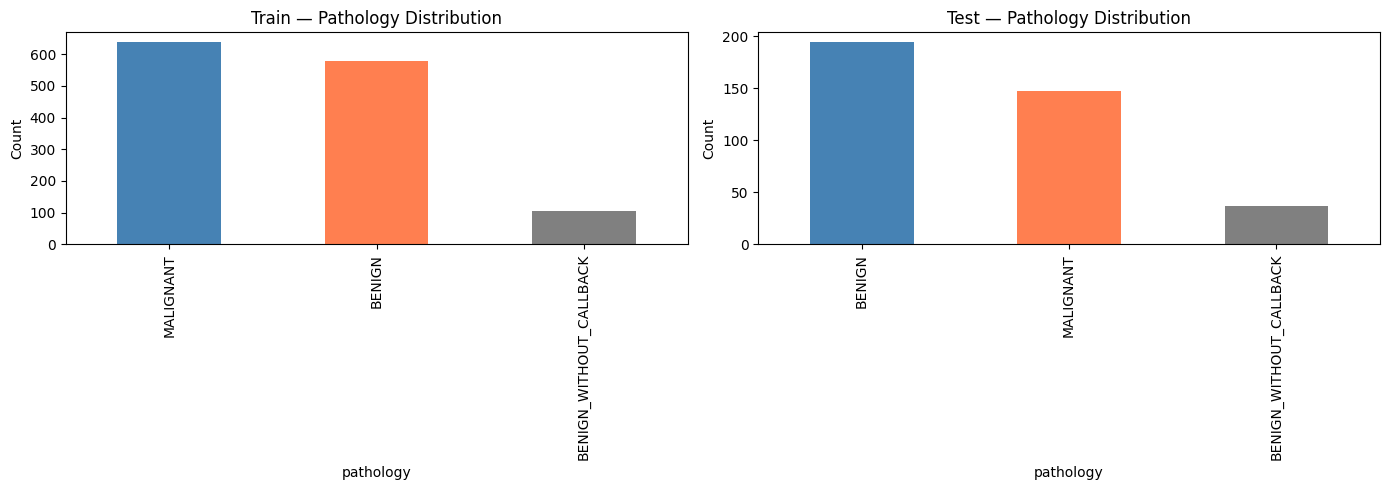

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_df["pathology"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "coral", "grey"])
axes[0].set_title("Train — Pathology Distribution")
axes[0].set_ylabel("Count")

test_df["pathology"].value_counts().plot(kind="bar", ax=axes[1], color=["steelblue", "coral", "grey"])
axes[1].set_title("Test — Pathology Distribution")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Binary Label (Benign vs Malignant)

In [9]:
train_df["label"] = (train_df["pathology"] == "MALIGNANT").astype(int)
test_df["label"]  = (test_df["pathology"]  == "MALIGNANT").astype(int)

print("Train label balance:")
print(train_df["label"].value_counts(normalize=True))
print("\nTest label balance:")
print(test_df["label"].value_counts(normalize=True))

Train label balance:
label
0    0.516692
1    0.483308
Name: proportion, dtype: float64

Test label balance:
label
0    0.611111
1    0.388889
Name: proportion, dtype: float64


## Metadata Feature Analysis

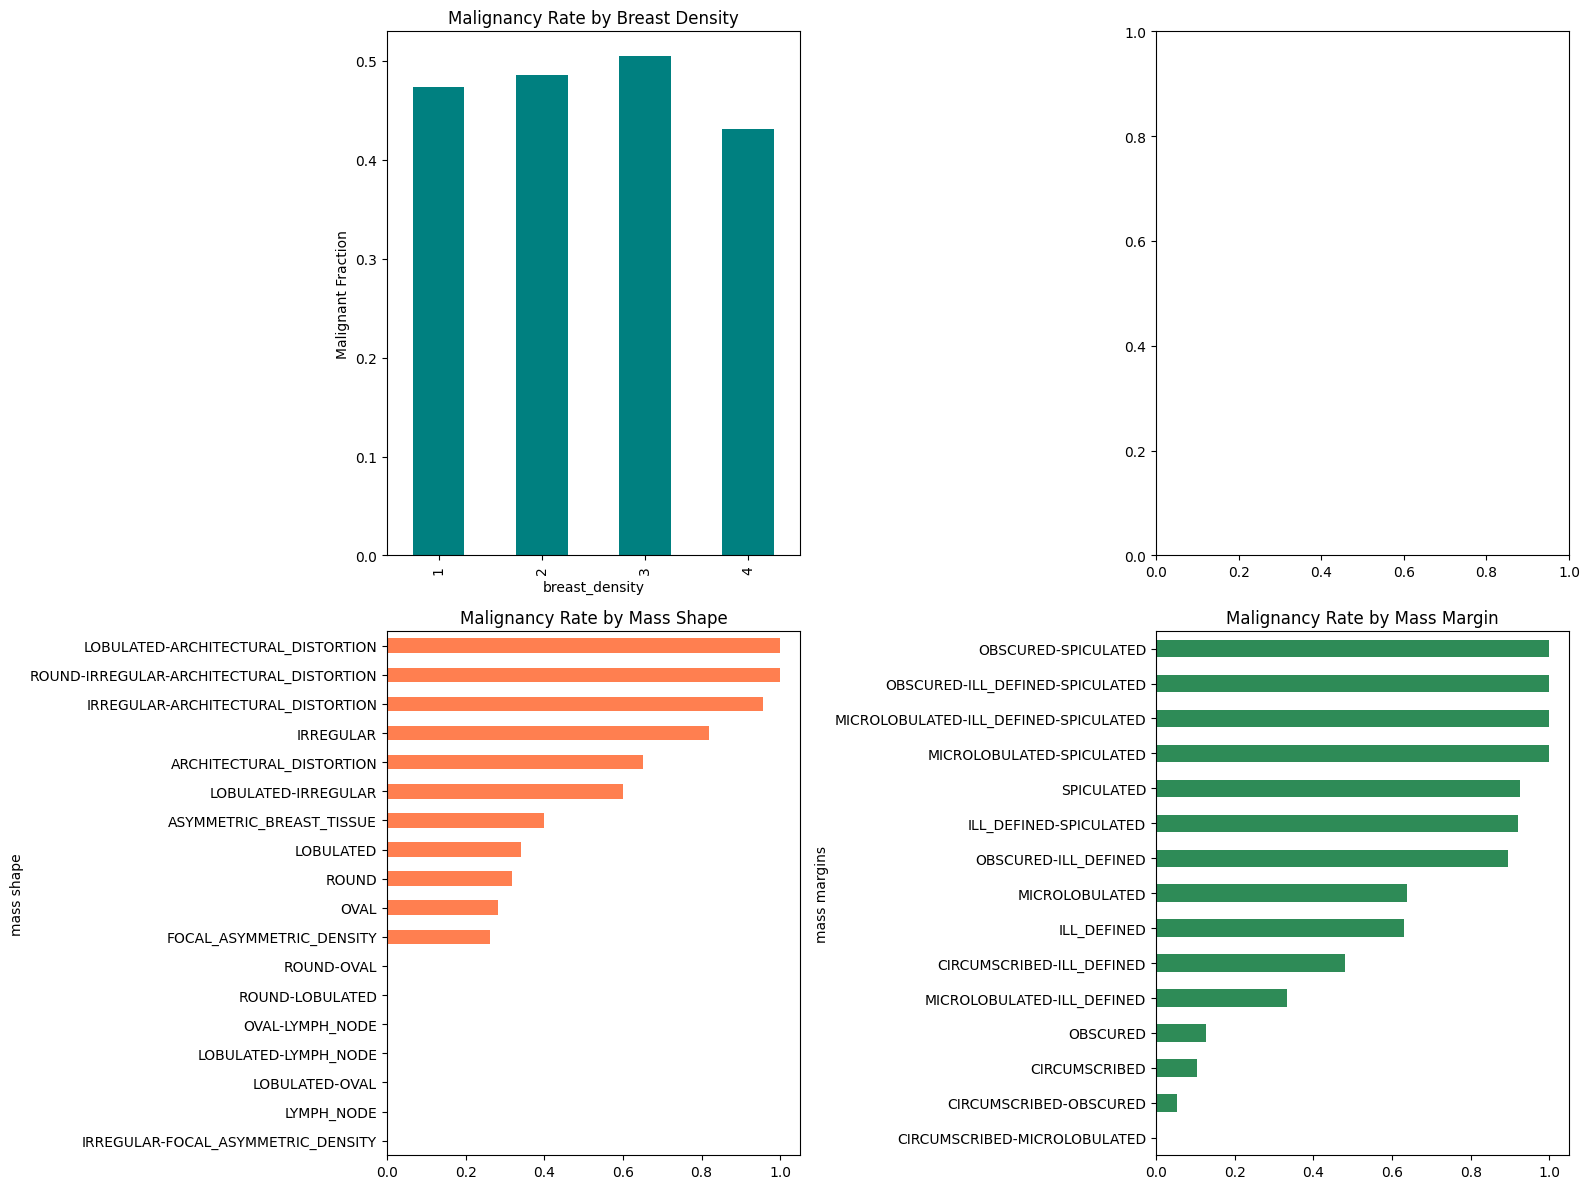

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

train_df.groupby("breast_density")["label"].mean().plot(kind="bar", ax=axes[0,0], color="teal")
axes[0,0].set_title("Malignancy Rate by Breast Density")
axes[0,0].set_ylabel("Malignant Fraction")

train_df["breast density"].value_counts().sort_index().plot(kind="bar", ax=axes[0,1], color="slateblue") \
    if "breast density" in train_df.columns else None

train_df.groupby("mass shape")["label"].mean().sort_values().plot(kind="barh", ax=axes[1,0], color="coral") \
    if "mass shape" in train_df.columns else None
axes[1,0].set_title("Malignancy Rate by Mass Shape")

train_df.groupby("mass margins")["label"].mean().sort_values().plot(kind="barh", ax=axes[1,1], color="seagreen") \
    if "mass margins" in train_df.columns else None
axes[1,1].set_title("Malignancy Rate by Mass Margin")

plt.tight_layout()
plt.show()

## Image Path Resolution

In [11]:
# Build a lookup index
print("Building image index...")
_image_index = {}
for _root, _dirs, _files in os.walk(os.path.join(BASE_DIR, "jpeg")):
    for _f in _files:
        if _f.endswith(".jpg"):
            _folder = os.path.basename(_root)
            if _folder not in _image_index:
                _image_index[_folder] = os.path.join(_root, _f)
print(f"Index built: {len(_image_index)} folders found")

def find_image(csv_path):
    parts = csv_path.split("/")
    return _image_index.get(parts[2])

# Verify
sample = find_image(train_df["image file path"].values[0])
print(f"Sample resolved path: {sample}")

Building image index...
Index built: 6774 folders found
Sample resolved path: /content/kaggle_datasets/jpeg/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/1-211.jpg


## Sample Images (Benign vs Malignant)

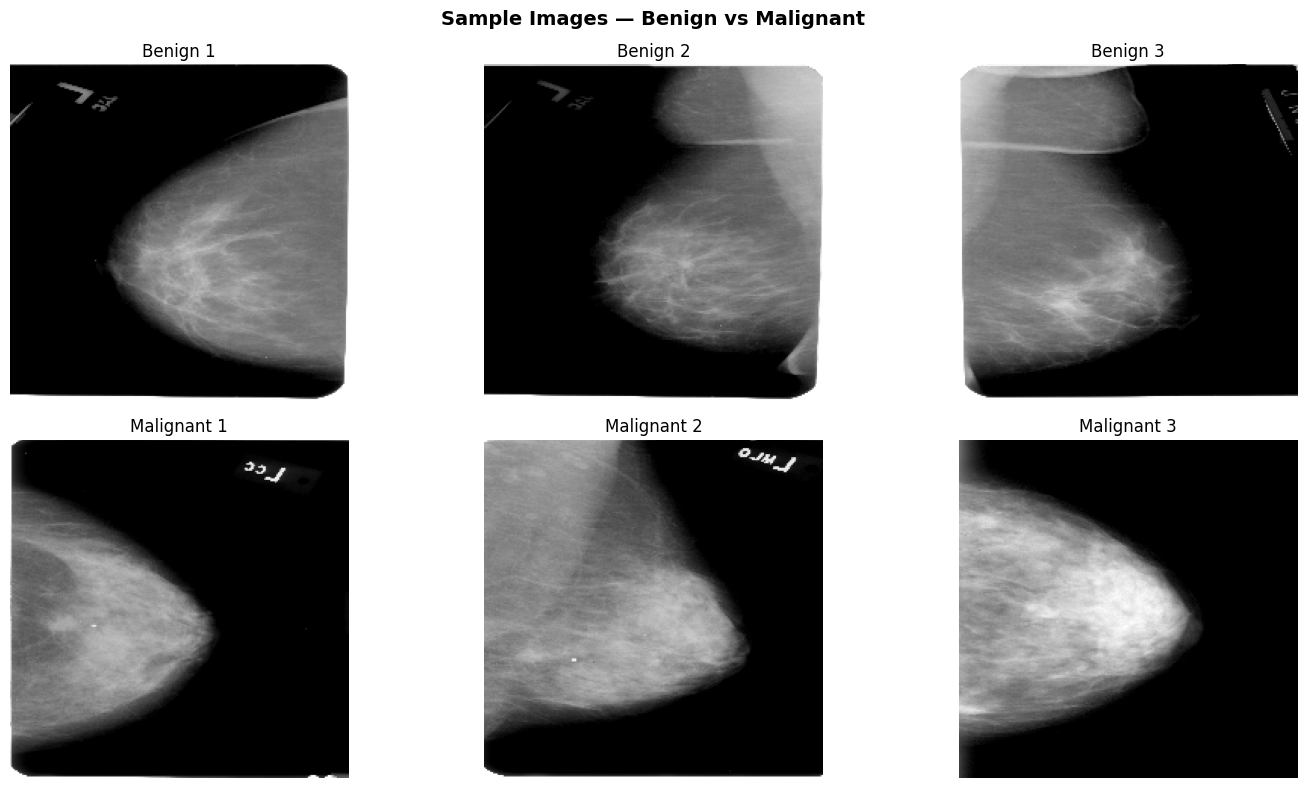

In [16]:
benign_paths    = train_df[train_df["label"]==0]["image file path"].values[:3]
malignant_paths = train_df[train_df["label"]==1]["image file path"].values[:3]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, path in enumerate(benign_paths):
    full_path = find_image(path)
    if full_path:
        img = cv2.imread(full_path, 0)
        img = cv2.resize(img, (224, 224))
        axes[0, i].imshow(img, cmap="gray")
        axes[0, i].set_title(f"Benign {i+1}")
        axes[0, i].axis("off")

for i, path in enumerate(malignant_paths):
    full_path = find_image(path)
    if full_path:
        img = cv2.imread(full_path, 0)
        img = cv2.resize(img, (224, 224))
        axes[1, i].imshow(img, cmap="gray")
        axes[1, i].set_title(f"Malignant {i+1}")
        axes[1, i].axis("off")

plt.suptitle("Sample Images — Benign vs Malignant", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Pixel Intensity Distribution

Loading 20 benign images...
Loading 20 malignant images...


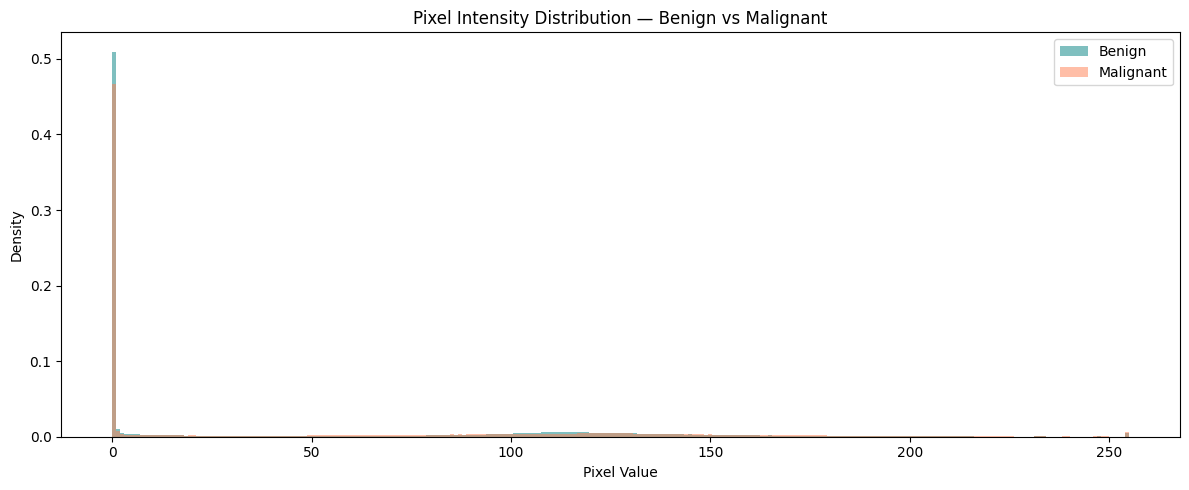

Mean pixel — Benign: 51.63, Malignant: 58.38


In [17]:
benign_pixels, malignant_pixels = [], []
print("Loading 20 benign images...")
for path in train_df[train_df["label"]==0]["image file path"].values[:20]:
    full_path = find_image(path)
    if full_path:
        img = cv2.imread(full_path, 0)
        if img is not None:
              benign_pixels.append(cv2.resize(img, (256, 256)).ravel())

print("Loading 20 malignant images...")
for path in train_df[train_df["label"]==1]["image file path"].values[:20]:
    full_path = find_image(path)
    if full_path:
        img = cv2.imread(full_path, 0)
        if img is not None:
              malignant_pixels.append(cv2.resize(img, (256, 256)).ravel())
benign_pixels = np.concatenate(benign_pixels)
malignant_pixels = np.concatenate(malignant_pixels)

plt.figure(figsize=(12, 5))
plt.hist(benign_pixels,    bins=256, alpha=0.5, color="teal",  label="Benign",    density=True)
plt.hist(malignant_pixels, bins=256, alpha=0.5, color="coral", label="Malignant", density=True)
plt.title("Pixel Intensity Distribution - Benign vs Malignant")
plt.xlabel("Pixel Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Mean pixel - Benign: {np.mean(benign_pixels):.2f}, Malignant: {np.mean(malignant_pixels):.2f}")

## Image Check

Looks at 50 mammograms to see how big they are. Since they are all different sizes, resize every image to the same size before training.

In [18]:
# Image size check (50 sample training images)
heights, widths = [], []
for p in train_df["image file path"].values[:50]:
    img = cv2.imread(find_image(p), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        heights.append(img.shape[0]); widths.append(img.shape[1])
print(f"Heights: {min(heights)}–{max(heights)} px, Widths: {min(widths)}–{max(widths)} px (n={len(heights)})")

Heights: 4424–6871 px, Widths: 2206–4411 px (n=50)


## Noise filter Comparison (PSNR / SSIM)

Adds synthetic Gaussian noise and salt-and-pepper noise to a sample mammogram resized to 512×512, then compares a 5×5 Gaussian filter against a 5×5 median filter using PSNR and SSIM.

Higher values mean the filtered image is closer to the clean original.

In [19]:
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

rng = np.random.default_rng(42)
clean = cv2.resize(cv2.imread(find_image(train_df["image file path"].values[0]), cv2.IMREAD_GRAYSCALE), (512, 512))

gauss_noisy = np.clip(clean + rng.normal(0, 10, clean.shape), 0, 255).astype(np.uint8)
sp_noisy = clean.copy()
mask = rng.random(clean.shape)
sp_noisy[mask < 0.025] = 0; sp_noisy[mask > 0.975] = 255

def score(noisy):
    g = cv2.GaussianBlur(noisy, (5, 5), 0)
    m = cv2.medianBlur(noisy, 5)
    return (psnr(clean, g), ssim(clean, g)), (psnr(clean, m), ssim(clean, m))

for name, noisy in [("Gaussian noise", gauss_noisy), ("Salt-and-pepper noise", sp_noisy)]:
    (pg, sg), (pm, sm) = score(noisy)
    print(f"{name}: Gaussian filter PSNR {pg:.2f} / SSIM {sg:.4f} | Median filter PSNR {pm:.2f} / SSIM {sm:.4f}")

Gaussian noise: Gaussian filter PSNR 30.41 / SSIM 0.5384 | Median filter PSNR 36.09 / SSIM 0.8682
Salt-and-pepper noise: Gaussian filter PSNR 25.66 / SSIM 0.3951 | Median filter PSNR 36.01 / SSIM 0.9589


## Image Preprocessing Pipeline
Applies CLAHE contrast enhancement, resizes to 224×224, converts grayscale to 3-channel RGB, and keeps pixel values in `[0, 255]`

EfficientNetB0 applies its own normalization internally.

In [20]:
IMG_SIZE = 224
CHANNELS = 3

def load_and_preprocess(csv_path, img_size=IMG_SIZE):
    full_path = find_image(csv_path)
    if full_path is None:
        return None
    img = cv2.imread(full_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    img = cv2.resize(img, (img_size, img_size))
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = img.astype(np.float32)
    return img

sample = load_and_preprocess(train_df["image file path"].values[0])
print(f"Sample shape: {sample.shape}, dtype: {sample.dtype}, range: {sample.min():.0f}-{sample.max():.0f}")

Sample shape: (224, 224, 3), dtype: float32, range: 2-255


## Build Dataset Arrays

Loads and preprocesses every train and test image. The resulting arrays are saved as `.npy` files in the Colab working directory (`/content`), so re-running this cell in the same session loads them instantly instead of rebuilding.

In [21]:
X_train_path = os.path.join(WORK_DIR, "X_train.npy")
y_train_path = os.path.join(WORK_DIR, "y_train.npy")
X_test_path  = os.path.join(WORK_DIR, "X_test.npy")
y_test_path  = os.path.join(WORK_DIR, "y_test.npy")

if os.path.exists(X_train_path):
    X_train = np.load(X_train_path)
    y_train = np.load(y_train_path)
    X_test  = np.load(X_test_path)
    y_test  = np.load(y_test_path)
    print(f"Loaded cached arrays - Train: {X_train.shape}, Test: {X_test.shape}")
else:
    def build_dataset(df, desc=""):
        X, y, missing = [], [], 0
        total = len(df)
        for i, (_, row) in enumerate(df.iterrows()):
            img = load_and_preprocess(row["image file path"])
            if img is not None:
                X.append(img)
                y.append(row["label"])
            else:
                missing += 1
            if (i+1) % 50 == 0:
                print(f"  {desc}: {i+1}/{total}...", flush=True)
        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.int32)
        print(f"{desc}: {X.shape[0]} images loaded, {missing} skipped")
        return X, y

    X_train, y_train = build_dataset(train_df, desc="Train")
    X_test,  y_test  = build_dataset(test_df,  desc="Test")
    np.save(X_train_path, X_train)
    np.save(y_train_path, y_train)
    np.save(X_test_path,  X_test)
    np.save(y_test_path,  y_test)
    print("Arrays saved to {WORK_DIR}")

print(f"Class balance - Train: {y_train.mean()*100:.1f}% malignant")
print(f"Class balance - Test:  {y_test.mean()*100:.1f}% malignant")

  Train: 50/1318...
  Train: 100/1318...
  Train: 150/1318...
  Train: 200/1318...
  Train: 250/1318...
  Train: 300/1318...
  Train: 350/1318...
  Train: 400/1318...
  Train: 450/1318...
  Train: 500/1318...
  Train: 550/1318...
  Train: 600/1318...
  Train: 650/1318...
  Train: 700/1318...
  Train: 750/1318...
  Train: 800/1318...
  Train: 850/1318...
  Train: 900/1318...
  Train: 950/1318...
  Train: 1000/1318...
  Train: 1050/1318...
  Train: 1100/1318...
  Train: 1150/1318...
  Train: 1200/1318...
  Train: 1250/1318...
  Train: 1300/1318...
Train: 1318 images loaded, 0 skipped
  Test: 50/378...
  Test: 100/378...
  Test: 150/378...
  Test: 200/378...
  Test: 250/378...
  Test: 300/378...
  Test: 350/378...
Test: 378 images loaded, 0 skipped
Arrays saved to {WORK_DIR}
Class balance — Train: 48.3% malignant
Class balance — Test:  38.9% malignant


## Train and Validation Split

Splits the CBIS-DDSM training set 80/20 into training (1,054) and validation (264) images, arranged by label so both keep the same benign/malignant ratio

The official test set (378) is left untouched until final evaluation.

In [22]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)
print(f"Train: {X_tr.shape}, Val: {X_val.shape}")

Train: (1054, 224, 224, 3), Val: (264, 224, 224, 3)


## tf.data Pipeline with Augmentation

In [23]:
import tensorflow as tf

BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=25.5)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, label

neg, pos = np.bincount(y_tr)
total = neg + pos
class_weight = {0: total / (2 * neg), 1: total / (2 * pos)}
print("Class weights:", class_weight)

train_ds = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
            .shuffle(len(X_tr), seed=42)
            .map(augment, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
          .batch(BATCH_SIZE).prefetch(AUTOTUNE))

print(f"Train batches: {len(train_ds)}, Val batches: {len(val_ds)}")

Class weights: {0: np.float64(0.9669724770642202), 1: np.float64(1.0353634577603144)}
Train batches: 33, Val batches: 9


## Baseline CNN
Trains a baseline CNN from scratch with no regularization.
Uses the baseline preprocessing pipeline: 5×5 Gaussian blur, resize to 64×64, and pixel values scaled to [0, 1]. No dropout, batch normalisation, augmentation or early stopping is used, so the model's overfitting behaviour
is visible. It is trained for 20 epochs on the same 80/20 train/validation split as EfficientNetB0, then evaluated once on the held-out test set at a 0.5 threshold.

Range: 0.0 1.0 | shape: (1318, 64, 64, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.5104 - auc: 0.4856 - loss: 0.6946 - val_accuracy: 0.5152 - val_auc: 0.6179 - val_loss: 0.6914
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5484 - auc: 0.5509 - loss: 0.6906 - val_accuracy: 0.5379 - val_auc: 0.5940 - val_loss: 0.6886
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5693 - auc: 0.5929 - loss: 0.6818 - val_accuracy: 0.5795 - val_auc: 0.5862 - val_loss: 0.6904
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5968 - auc: 0.6356 - loss: 0.6679 - val_accuracy: 0.5871 - val_auc: 0.6105 - val_loss: 0.6928
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6243 - auc: 0.6796 - loss: 0.6452 - val_accuracy: 0.6136 - val_auc: 0.6453 - val_loss: 0.6880
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6717 - auc: 0.7184 - loss: 0.6162 - val_accuracy: 0.6250 - val_auc: 0.6573 - val_loss: 0.6955
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms

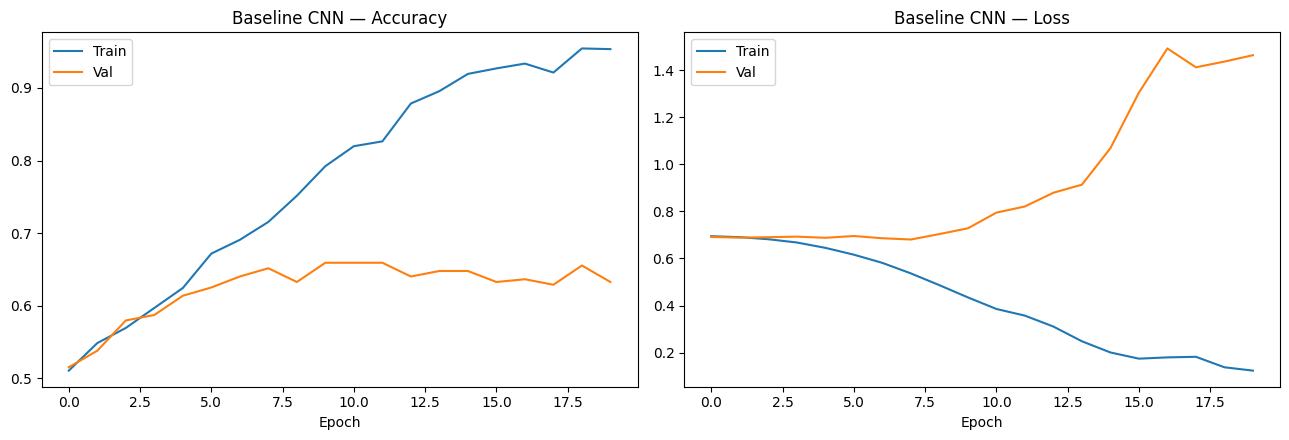

In [24]:
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix
tf.keras.utils.set_random_seed(42)

def load_baseline(csv_path, size=64):
    img = cv2.imread(find_image(csv_path), cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    img = cv2.GaussianBlur(img, (5, 5), 0)
    img = cv2.resize(img, (size, size))
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return img.astype(np.float32) / 255.0          # [0, 1]

Xb_train = np.array([load_baseline(p) for p in train_df["image file path"]])
Xb_test  = np.array([load_baseline(p) for p in test_df["image file path"]])
yb_train, yb_test = train_df["label"].values, test_df["label"].values
print("Range:", Xb_train.min(), Xb_train.max(), "| shape:", Xb_train.shape)

Xb_tr, Xb_val, yb_tr, yb_val = train_test_split(Xb_train, yb_train, test_size=0.2,
                                                stratify=yb_train, random_state=42)

baseline = tf.keras.Sequential([
    tf.keras.Input(shape=(64, 64, 3)),
    layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
baseline.compile(optimizer=Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy", AUC(name="auc")])
baseline.summary()

hist_b = baseline.fit(Xb_tr, yb_tr, validation_data=(Xb_val, yb_val), epochs=20, batch_size=32, verbose=1)

# Test-set evaluation (threshold 0.5)
pb = baseline.predict(Xb_test, verbose=0).ravel()
tn, fp, fn, tp = confusion_matrix(yb_test, (pb >= 0.5).astype(int)).ravel()
print(f"Baseline TEST  AUC {roc_auc_score(yb_test, pb):.4f} | Sens {tp/(tp+fn):.3f} | Spec {tn/(tn+fp):.3f} | Acc {(tp+tn)/len(yb_test):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, k in zip(ax, ["accuracy", "loss"]):
    a.plot(hist_b.history[k], label="Train"); a.plot(hist_b.history[f"val_{k}"], label="Val")
    a.set_title(f"Baseline CNN — {k.title()}"); a.set_xlabel("Epoch"); a.legend()
plt.tight_layout(); plt.show()

## Build Model

In [22]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

def build_model(img_size=IMG_SIZE, lr=1e-3):
    base = EfficientNetB0(include_top=False, weights="imagenet",
                          input_shape=(img_size, img_size, CHANNELS))
    base.trainable = False

    inputs = tf.keras.Input(shape=(img_size, img_size, CHANNELS))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(lr), loss="binary_crossentropy",
                  metrics=["accuracy", AUC(name="auc")])
    return model

model = build_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

## Phase 1: Train Classification Head (Frozen Backbone)
The EfficientNetB0 backbone is frozen and only the new classification head is trained.

Callbacks:
- **EarlyStopping** stops training if `val_auc` does not improve for 8 epochs, and restores the best weights.
- **ModelCheckpoint** saves the best model (highest `val_auc`) to `/content/best_model.keras`.
- **ReduceLROnPlateau** halves the learning rate if `val_auc` stalls for 4 epochs.

The same checkpoint file is updated during Phase 2 fine-tuning. The final model is then downloaded for use in the Streamlit app.

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

MODEL_PATH = os.path.join(WORK_DIR, "best_model.keras")

callbacks = [
    EarlyStopping(monitor="val_auc", patience=8, mode="max", restore_best_weights=True, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor="val_auc", mode="max", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_auc", factor=0.5, patience=4, mode="max", verbose=1, min_lr=1e-7),
]

print("=== Phase 1: Training classification head (backbone frozen) ===")
history1 = model.fit(train_ds, validation_data=val_ds, epochs=25,
                     class_weight=class_weight, callbacks=callbacks, verbose=1)

=== Phase 1: Training classification head (backbone frozen) ===
Epoch 1/25
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.5477 - auc: 0.5776 - loss: 0.9190
Epoch 1: val_auc improved from None to 0.66047, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5474 - auc: 0.5783 - loss: 0.9314 - val_accuracy: 0.5455 - val_auc: 0.6605 - val_loss: 0.6733 - learning_rate: 0.0010
Epoch 2/25
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6180 - auc: 0.6647 - loss: 0.8015
Epoch 2: val_auc improved from 0.66047 to 0.66372, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6186 - auc: 0.6684 - loss: 0.7950 - val_accuracy: 0.5682 - val_auc: 0.6637 - val_loss: 0.6587 - learning_rate: 0.0010
Epoch 3/25
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6562 - auc: 0.7241 - los

## Phase 2: Fine-tune Top Backbone Layers

Lets the top 30 layers of EfficientNetB0 keep learning and fine-tunes them on mammograms with a small learning rate, so the model adapts to breast images without forgetting what it already learned. Training stops once validation AUC stops improving.

In [24]:
base_model = model.layers[1]
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Trainable backbone layers: {sum(1 for l in base_model.layers if l.trainable)}/{len(base_model.layers)}")

model.compile(optimizer=Adam(1e-4), loss="binary_crossentropy",
              metrics=["accuracy", AUC(name="auc")])

print("=== Phase 2: Fine-tuning top backbone layers ===")
history2 = model.fit(train_ds, validation_data=val_ds, epochs=30,
                     class_weight=class_weight, callbacks=callbacks, verbose=1)

Trainable backbone layers: 30/238
=== Phase 2: Fine-tuning top backbone layers ===
Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.6769 - auc: 0.7305 - loss: 0.6570
Epoch 1: val_auc improved from 0.76143 to 0.77051, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 64s 989ms/step - accuracy: 0.6860 - auc: 0.7361 - loss: 0.6559 - val_accuracy: 0.6856 - val_auc: 0.7705 - val_loss: 0.5992 - learning_rate: 1.0000e-04
Epoch 2/30
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6532 - auc: 0.7338 - loss: 0.6299
Epoch 2: val_auc did not improve from 0.77051
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.6736 - auc: 0.7464 - loss: 0.6204 - val_accuracy: 0.7045 - val_auc: 0.7639 - val_loss: 0.5944 - learning_rate: 1.0000e-04
Epoch 3/30
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7004 - auc: 0.7832 - loss: 0.5757
Epoch 3: val_auc did not improve from 0.77051
33/33 ━━━━━━━━━━━━━

## Model Download

In [25]:
from google.colab import files

print(f"Downloading {MODEL_PATH} to your computer's Downloads folder...")
files.download(MODEL_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Training History Plots

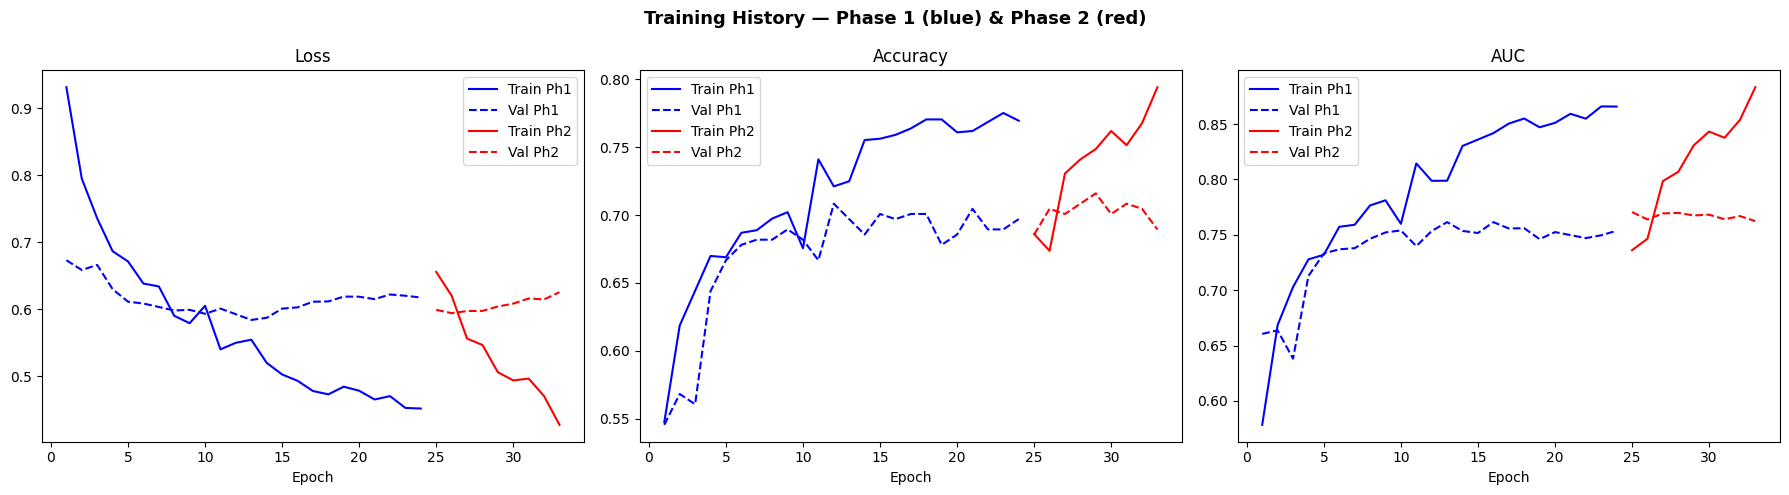

In [26]:
def plot_history(h1, h2=None):
    keys   = ["loss", "accuracy", "auc"]
    labels = ["Loss", "Accuracy", "AUC"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, key, label in zip(axes, keys, labels):
        e1 = len(h1.history[key])
        ax.plot(range(1, e1+1), h1.history[key],          "b-",  label="Train Ph1")
        ax.plot(range(1, e1+1), h1.history[f"val_{key}"], "b--", label="Val Ph1")
        if h2:
            e2 = len(h2.history[key])
            ax.plot(range(e1+1, e1+e2+1), h2.history[key],          "r-",  label="Train Ph2")
            ax.plot(range(e1+1, e1+e2+1), h2.history[f"val_{key}"], "r--", label="Val Ph2")
        ax.set_title(label)
        ax.set_xlabel("Epoch")
        ax.legend()
    plt.suptitle("Training History — Phase 1 (blue) & Phase 2 (red)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_history(history1, history2)

## Validation Evaluation

9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 889ms/step
=== Classification Report (Validation) ===
              precision    recall  f1-score   support

      Benign       0.74      0.60      0.66       136
   Malignant       0.65      0.78      0.71       128

    accuracy                           0.69       264
   macro avg       0.69      0.69      0.68       264
weighted avg       0.70      0.69      0.68       264

ROC-AUC: 0.7705
Sensitivity (Recall for Malignant): 0.781
Specificity (Recall for Benign):    0.596


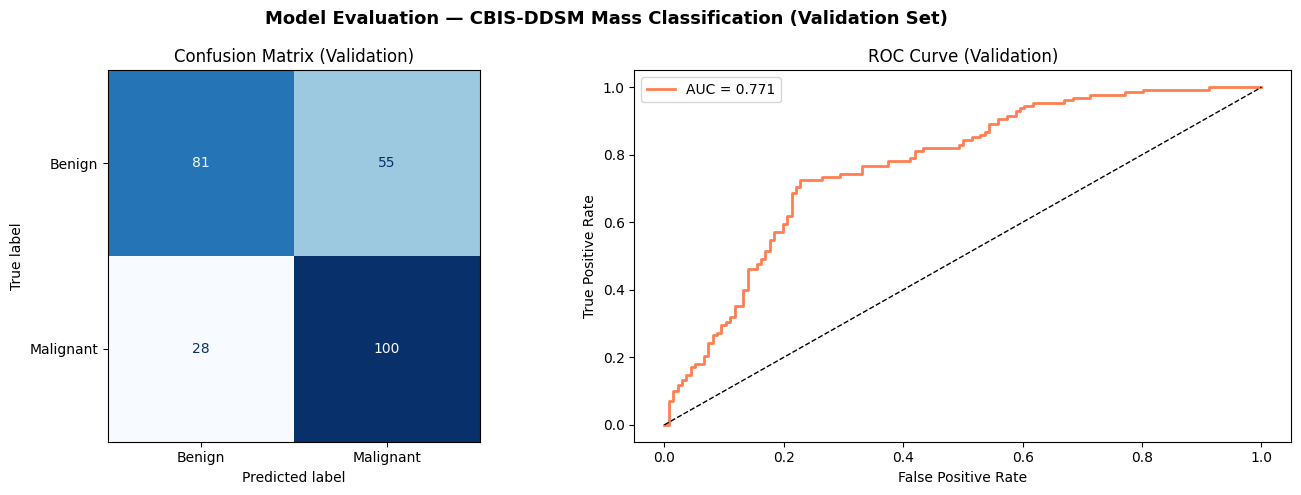

In [27]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

model.load_weights(MODEL_PATH)

y_prob = model.predict(val_ds, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("=== Classification Report (Validation) ===")
print(classification_report(y_val, y_pred, target_names=["Benign", "Malignant"]))

auc_score = roc_auc_score(y_val, y_prob)
print(f"ROC-AUC: {auc_score:.4f}")

cm = confusion_matrix(y_val, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"Sensitivity (Recall for Malignant): {tp/(tp+fn):.3f}")
print(f"Specificity (Recall for Benign):    {tn/(tn+fp):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=["Benign","Malignant"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Validation)")

fpr, tpr, thresholds = roc_curve(y_val, y_prob)
axes[1].plot(fpr, tpr, color="coral", lw=2, label=f"AUC = {auc_score:.3f}")
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Validation)")
axes[1].legend()

plt.suptitle("Model Evaluation — CBIS-DDSM Mass Classification (Validation Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Decision Threshold Selction on the Validation Set

Chooses the classification threshold using the validation ROC curve only, so the test set plays no part in the choice.

Option A shows the thresholds needed to reach 80% and 90% sensitivity, which
illustrates the sensitivity/specificity trade-off.

Option B selects the Youden's J-optimal threshold
(0.591), which maximises sensitivity + specificity and is used for the final test evaluation.

In [28]:
# Option A: pick a threshold that hits a target sensitivity
target_sensitivity = 0.80
idx = np.argmin(np.abs(tpr - target_sensitivity))
print(f"Target sensitivity 0.80 -> threshold {thresholds[idx]:.4f}, "
      f"actual sensitivity {tpr[idx]:.3f}, specificity {1 - fpr[idx]:.3f}")

target_sensitivity = 0.90
idx = np.argmin(np.abs(tpr - target_sensitivity))
print(f"Target sensitivity 0.90 -> threshold {thresholds[idx]:.4f}, "
      f"actual sensitivity {tpr[idx]:.3f}, specificity {1 - fpr[idx]:.3f}")

# Option B: Youden's J statistic threshold
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
print(f"Youden's J-optimal threshold: {thresholds[best_idx]:.4f} -> "
      f"sensitivity {tpr[best_idx]:.3f}, specificity {1 - fpr[best_idx]:.3f}")

Target sensitivity 0.80 -> threshold 0.4958, actual sensitivity 0.789, specificity 0.588
Target sensitivity 0.90 -> threshold 0.3509, actual sensitivity 0.906, specificity 0.441
Youden's J-optimal threshold: 0.5910 -> sensitivity 0.727, specificity 0.772


## Held-Out Test Set Final Evaluation

Evaluates the final EfficientNetB0 model once on the 378-image CBIS-DDSM test set, using the decision threshold chosen on the validation set in the previous step. This is the only time the test set is used.

12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step
=== Classification Report (Test, threshold = 0.591) ===
              precision    recall  f1-score   support

      Benign       0.72      0.73      0.72       231
   Malignant       0.56      0.54      0.55       147

    accuracy                           0.66       378
   macro avg       0.64      0.64      0.64       378
weighted avg       0.66      0.66      0.66       378

ROC-AUC:     0.7092
Sensitivity: 0.544  (80/147 malignant detected)
Specificity: 0.732  (169/231 benign correct)


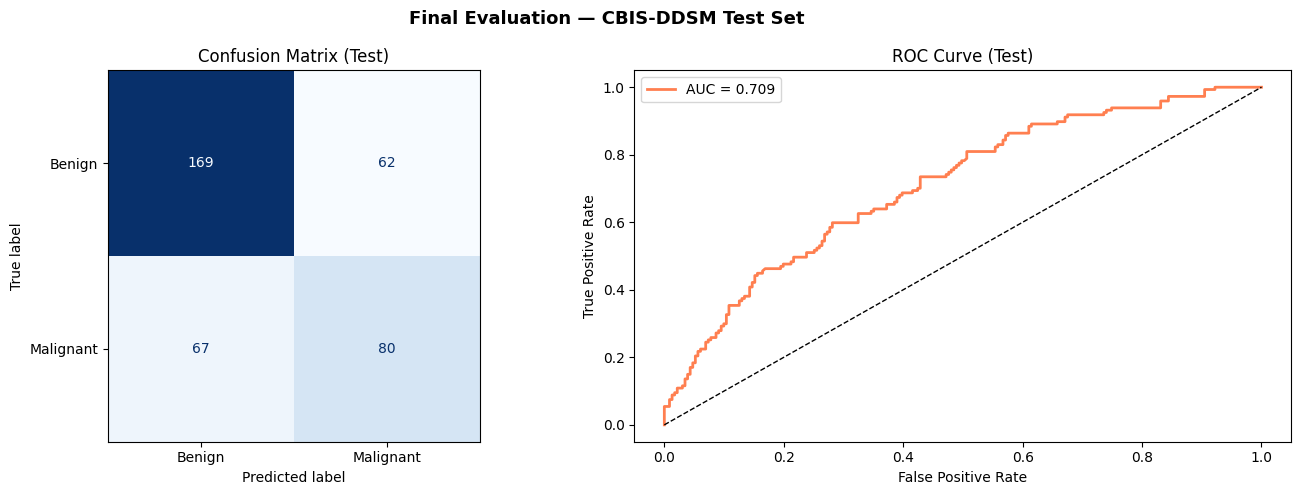

In [29]:
THRESHOLD = thresholds[best_idx]   # Youden threshold chosen on validation

y_prob_test = model.predict(X_test, batch_size=32, verbose=1).ravel()
y_pred_test = (y_prob_test >= THRESHOLD).astype(int)

print(f"=== Classification Report (Test, threshold = {THRESHOLD:.3f}) ===")
print(classification_report(y_test, y_pred_test, target_names=["Benign", "Malignant"]))

test_auc = roc_auc_score(y_test, y_prob_test)
cm_test = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm_test.ravel()
print(f"ROC-AUC:     {test_auc:.4f}")
print(f"Sensitivity: {tp/(tp+fn):.3f}  ({tp}/{tp+fn} malignant detected)")
print(f"Specificity: {tn/(tn+fp):.3f}  ({tn}/{tn+fp} benign correct)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm_test, display_labels=["Benign", "Malignant"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Test)")
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_test)
axes[1].plot(fpr_t, tpr_t, color="coral", lw=2, label=f"AUC = {test_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Test)"); axes[1].legend()
plt.suptitle("Final Evaluation - CBIS-DDSM Test Set", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## Sample Predictions on Test Images

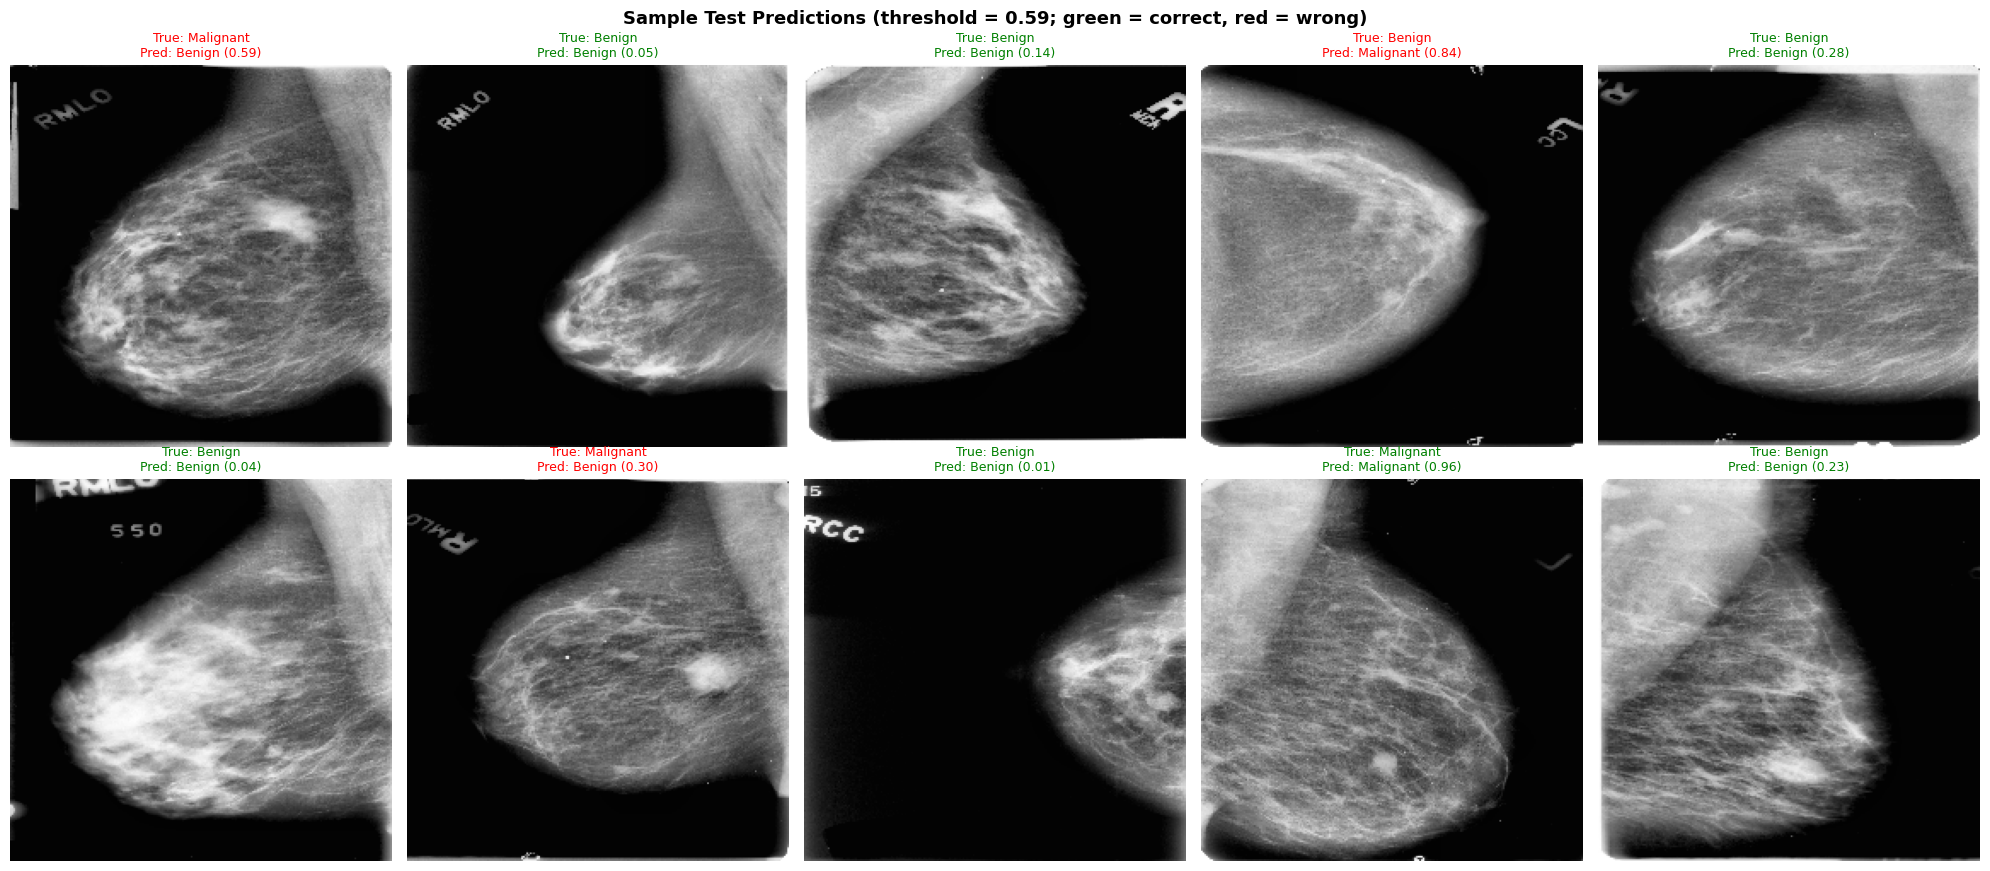

In [31]:
fig, axes = plt.subplots(2, 5, figsize=(20, 9))

rng = np.random.default_rng(42)
indices = rng.choice(len(X_test), 10, replace=False)

THRESHOLD = thresholds[best_idx]

probs = model.predict(X_test[indices], verbose=0).ravel()

for ax, idx, prob in zip(axes.ravel(), indices, probs):
    img = X_test[idx]
    true_label = "Malignant" if y_test[idx] == 1 else "Benign"
    pred_label = "Malignant" if prob >= THRESHOLD else "Benign"
    color = "green" if pred_label == true_label else "red"
    ax.imshow(img.astype(np.uint8), cmap="gray")
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({prob:.2f})", color=color, fontsize=9)
    ax.axis("off")

plt.suptitle(f"Sample Test Predictions (threshold = {THRESHOLD:.2f}; green = correct, red = wrong)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()